# Online Retail Sales Analysis

Exploratory analysis of transactional data from a UK-based online retailer.

## Project objective

The objective is to analyze sales, customers, products, cancellations, and revenue trends and provide practical business recommendations.

In [2]:
from pathlib import Path
from google.colab import drive

drive.mount("/content/drive")

PROJECT_DIR = Path(
    "/content/drive/MyDrive/online-retail-analysis"
)

DATA_DIR = PROJECT_DIR / "data"
IMAGES_DIR = PROJECT_DIR / "images"

IMAGES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project directory: {PROJECT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/online-retail-analysis


In [3]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

In [4]:
data_path = DATA_DIR / "online_retail.xlsx"

df = pd.read_excel(data_path)

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
print(f"Amount of rows: {df.shape[0]}")
print(f"Amount of columns: {df.shape[1]}")

df.info()

Amount of rows: 541909
Amount of columns: 8
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [7]:
# Summarize data types, missing values, and unique values
quality_report = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_values": df.isnull().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2),
    "unique_values": df.nunique(),
})

quality_report

,data_type,missing_values,missing_percentage,unique_values
InvoiceNo,object,0,0.00,25900
StockCode,object,0,0.00,4070
Description,object,1454,0.27,4223
Quantity,int64,0,0.00,722
InvoiceDate,datetime64[ns],0,0.00,23260
UnitPrice,float64,0,0.00,1630
CustomerID,float64,135080,24.93,4372
Country,object,0,0.00,38


In [8]:
# These issues can distort revenue and sales volume
print(f"Duplicated rows: {df.duplicated().sum():,}")
print(f"Rows with Quantity <= 0: {(df['Quantity'] <= 0).sum()}")
print(f"Rows with UnitPrice <= 0: {(df['UnitPrice'] <= 0).sum()}")

Duplicated rows: 5,268
Rows with Quantity <= 0: 10624
Rows with UnitPrice <= 0: 2517


## Data cleaning

The dataset contains missing values, duplicate rows, cancelled transactions, and records with non-positive quantities or prices. These records are examined and filtered before sales analysis.

In [9]:
# Work on a copy to keep the raw data unchanged
sales_df = df.copy()

In [10]:
duplicate_count = sales_df.duplicated().sum()
sales_df = sales_df.drop_duplicates()

print(f"Removed {duplicate_count:,} duplicated rows. New shape: {sales_df.shape}")

Removed 5,268 duplicated rows. New shape: (536641, 8)


In [11]:
# In this dataset, cancelled invoice numbers start with C
sales_df["Cancelled"] = (
    sales_df["InvoiceNo"]
    .astype(str)
    .str.startswith("C")
)

cancelled_rows = sales_df["Cancelled"].sum()
cancelled_invoices = sales_df.loc[
    sales_df["Cancelled"],
    "InvoiceNo"
].nunique()

print(f"Cancelled rows: {cancelled_rows:,}")
print(f"Cancelled invoices: {cancelled_invoices:,}")

Cancelled rows: 9,251
Cancelled invoices: 3,836


In [12]:
sales_df.loc[
    sales_df["Cancelled"],
    ["InvoiceNo", "Quantity", "UnitPrice", "Description"]
].head(10)

,InvoiceNo,Quantity,UnitPrice,Description
141,C536379,-1,27.50,Discount
154,C536383,-1,4.65,SET OF 3 COLOURED FLYING DUCKS
235,C536391,-12,1.65,PLASTERS IN TIN CIRCUS PARADE
236,C536391,-24,0.29,PACK OF 12 PINK PAISLEY TISSUES
237,C536391,-24,0.29,PACK OF 12 BLUE PAISLEY TISSUES
238,C536391,-24,0.29,PACK OF 12 RED RETROSPOT TISSUES
239,C536391,-12,3.45,CHICK GREY HOT WATER BOTTLE
240,C536391,-12,1.65,PLASTERS IN TIN VINTAGE PAISLEY
241,C536391,-24,1.65,PLASTERS IN TIN SKULLS
939,C536506,-6,4.25,JAM MAKING SET WITH JARS


In [13]:
# Analyze positive sales first; cancellations are examined separately
sales_df = sales_df.loc[~sales_df["Cancelled"]].copy()

In [14]:
sales_df = sales_df.loc[
    (sales_df["Quantity"] > 0)
    & (sales_df["UnitPrice"] > 0)
    & (sales_df["Description"].notna())
].copy()

print(f"Rows after cleaning: {sales_df.shape[0]}")

Rows after cleaning: 524878


In [15]:
# Int64 keeps CustomerID integer-valued while allowing missing values
sales_df["CustomerID"] = sales_df["CustomerID"].astype("Int64")
sales_df["InvoiceDate"] = pd.to_datetime(sales_df["InvoiceDate"])

In [16]:
sales_df["Revenue"] = (
    sales_df["Quantity"]
    * sales_df["UnitPrice"]
)

sales_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Cancelled,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,False,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,False,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,False,20.34


In [17]:
sales_df[[
    "InvoiceNo",
    "Description",
    "Quantity",
    "UnitPrice",
    "Revenue"
]].head(10)

,InvoiceNo,Description,Quantity,UnitPrice,Revenue
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,15.30
1,536365,WHITE METAL LANTERN,6,3.39,20.34
2,536365,CREAM CUPID HEARTS COAT HANGER,8,2.75,22.00
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,20.34
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,20.34
5,536365,SET 7 BABUSHKA NESTING BOXES,2,7.65,15.30
6,536365,GLASS STAR FROSTED T-LIGHT HOLDER,6,4.25,25.50
7,536366,HAND WARMER UNION JACK,6,1.85,11.10
8,536366,HAND WARMER RED POLKA DOT,6,1.85,11.10
9,536367,ASSORTED COLOUR BIRD ORNAMENT,32,1.69,54.08


In [18]:
# Validate data quality after cleaning
cleaning_report = pd.Series({
    "Rows": len(sales_df),
    "Missing descriptions": sales_df["Description"].isna().sum(),
    "Cancelled rows": sales_df["Cancelled"].sum(),
    "Non-positive quantities": (sales_df["Quantity"] <= 0).sum(),
    "Non-positive prices": (sales_df["UnitPrice"] <= 0).sum(),
    "Duplicate rows": sales_df.duplicated().sum()
})

cleaning_report

,0
Rows,524878
Missing descriptions,0
Cancelled rows,0
Non-positive quantities,0
Non-positive prices,0
Duplicate rows,0


In [19]:
# One invoice may contain multiple product lines
orders = (
    sales_df
    .groupby("InvoiceNo", as_index=False)
    .agg(OrderRevenue=("Revenue", "sum"))
)

# Since cancellations are excluded, total_revenue currently represents gross revenue
total_revenue = sales_df["Revenue"].sum()
total_orders = sales_df["InvoiceNo"].nunique()
average_order_value = orders["OrderRevenue"].mean()
total_customers = sales_df["CustomerID"].nunique()
total_products = sales_df["StockCode"].nunique()

print(f"Period: {sales_df['InvoiceDate'].min().date()} - {sales_df['InvoiceDate'].max().date()}")
print(f"Total revenue: £{total_revenue:,.2f}")
print(f"Total orders: {total_orders:,}")
print(f"Average order value: £{average_order_value:,.2f}")
print(f"Identified customers: {total_customers:,}")
print(f"Total products: {total_products:,}")

Period: 2010-12-01 - 2011-12-09
Total revenue: £10,642,110.80
Total orders: 19,960
Average order value: £533.17
Identified customers: 4,338
Total products: 3,922


## Monthly sales analysis

Monthly revenue and order activity are analyzed to identify sales trends and seasonal changes.

In [20]:
# Normalize dates to month start for monthly aggregation
sales_df["Month"] = (
    sales_df["InvoiceDate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_sales = (
    sales_df
    .groupby("Month", as_index=False)
    .agg(
        MonthlyRevenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique"),
        Customers=("CustomerID", "nunique")
    )
)

# Explicit float conversion prevents a seaborn plotting error
monthly_sales["MonthlyRevenue"] = pd.to_numeric(
    monthly_sales["MonthlyRevenue"]
).astype(float)

monthly_sales

,Month,MonthlyRevenue,Orders,Customers
0,2010-12-01,821452.730,1559,885
1,2011-01-01,689811.610,1086,741
2,2011-02-01,522545.560,1100,758
3,2011-03-01,716215.260,1454,974
4,2011-04-01,536968.491,1246,856
5,2011-05-01,769296.610,1681,1056
6,2011-06-01,760547.010,1533,991
7,2011-07-01,718076.121,1475,949
8,2011-08-01,757841.380,1361,935
9,2011-09-01,1056435.192,1837,1266


In [21]:
# Exclude December 2011 because data is available only through December 9
complete_months = monthly_sales.loc[
    monthly_sales["Month"] < pd.Timestamp("2011-12-01")
].copy()

complete_months.dtypes

,0
Month,datetime64[ns]
MonthlyRevenue,float64
Orders,int64
Customers,int64


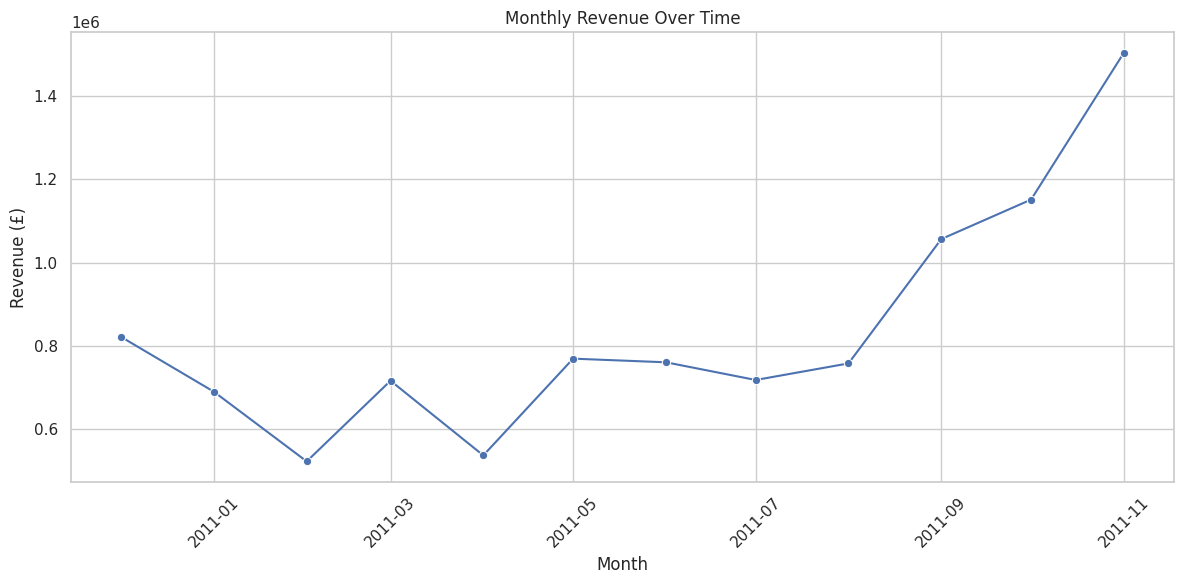

In [22]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=complete_months,
    x="Month",
    y="MonthlyRevenue",
    marker="o"
)

plt.title("Monthly Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")
plt.xticks(rotation=45)
plt.tight_layout()

# Save the chart for the project README
plt.savefig(
    IMAGES_DIR / "monthly_revenue.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [23]:
best_month = complete_months.loc[
    complete_months["MonthlyRevenue"].idxmax()
]
worst_month = complete_months.loc[
    complete_months["MonthlyRevenue"].idxmin()
]

print(
    f"Best month: {best_month['Month'].strftime('%B %Y')} "
    f"with revenue £{best_month['MonthlyRevenue']:,.2f}"
)
print(
    f"Worst month: {worst_month['Month'].strftime('%B %Y')} "
    f"with revenue £{worst_month['MonthlyRevenue']:,.2f}"
)

Best month: November 2011 with revenue £1,503,866.78
Worst month: February 2011 with revenue £522,545.56


In [24]:
complete_months["RevenueGrowthPct"] = (
    complete_months["MonthlyRevenue"]
    .pct_change()
    .mul(100)
    .round(2)
)

complete_months

,Month,MonthlyRevenue,Orders,Customers,RevenueGrowthPct
0,2010-12-01,821452.730,1559,885,NaN
1,2011-01-01,689811.610,1086,741,-16.03
2,2011-02-01,522545.560,1100,758,-24.25
3,2011-03-01,716215.260,1454,974,37.06
4,2011-04-01,536968.491,1246,856,-25.03
5,2011-05-01,769296.610,1681,1056,43.27
6,2011-06-01,760547.010,1533,991,-1.14
7,2011-07-01,718076.121,1475,949,-5.58
8,2011-08-01,757841.380,1361,935,5.54
9,2011-09-01,1056435.192,1837,1266,39.40


### Key findings

- Monthly revenue reached its lowest level in February 2011 at £522,545.56.
- Revenue recovered in March and increased considerably during the final months of 2011.
- September, October, and November generated revenue growth of 39.40%, 8.98%, and 30.63%, respectively.
- November 2011 was the strongest complete month, generating £1,503,866.78 in revenue from 2,769 orders.
- The increase in revenue was accompanied by growth in both the number of orders and identified customers.
- This pattern suggests strong seasonal demand before the Christmas period.
- December 2011 was excluded from the comparison because the dataset contains transactions only through December 9.

## Product analysis

Products are compared by total revenue, units sold, and number of orders to identify the most commercially important items.

In [25]:
# Numeric StockCodes exclude postage, discounts, and administrative entries
product_df = sales_df.loc[
    sales_df["StockCode"]
    .astype(str)
    .str[0]
    .str.isdigit()
].copy()

product_df["Description"] = product_df["Description"].str.strip()

In [26]:
product_summary = (
    product_df
    .groupby("StockCode")
    .agg(
        # Use the most frequent name because one product code may have spelling variations
        ProductName=(
            "Description",
            lambda values: values.mode().iat[0]
        ),
        UnitsSold=("Quantity", "sum"),
        Revenue=("Revenue", "sum"),
        Orders=("InvoiceNo", "nunique")
    )
    .reset_index()
)

product_summary.head()

,StockCode,ProductName,UnitsSold,Revenue,Orders
0,10002,INFLATABLE POLITICAL GLOBE,860,759.89,71
1,10080,GROOVY CACTUS INFLATABLE,303,119.09,22
2,10120,DOGGY RUBBER,192,40.32,29
3,10125,MINI FUNKY DESIGN TAPES,1295,993.99,91
4,10133,COLOURING PENCILS BROWN TUBE,2856,1539.60,196


In [27]:
top_by_revenue = product_summary.nlargest(10, "Revenue")
top_by_units = product_summary.nlargest(10, "UnitsSold")
top_by_orders = product_summary.nlargest(10, "Orders")

In [28]:
print("top_by_revenue:")
display(top_by_revenue.head())

print("top_by_orders:")
display(top_by_orders.head())

print("top_by_units:")
display(top_by_units.head())

top_by_revenue:


,StockCode,ProductName,UnitsSold,Revenue,Orders
1235,22423,REGENCY CAKESTAND 3 TIER,13851,174156.54,1988
2390,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
3539,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37641,104462.75,2198
2468,47566,PARTY BUNTING,18283,99445.23,1685
3528,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089


top_by_orders:


,StockCode,ProductName,UnitsSold,Revenue,Orders
3539,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37641,104462.75,2198
3528,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089
1235,22423,REGENCY CAKESTAND 3 TIER,13851,174156.54,1988
2468,47566,PARTY BUNTING,18283,99445.23,1685
100,20725,LUNCH BAG RED RETROSPOT,19432,35862.36,1565


top_by_units:


,StockCode,ProductName,UnitsSold,Revenue,Orders
2390,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
1945,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247
1034,22197,POPCORN HOLDER,56898,51334.47,1392
2562,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,13814.01,535
3528,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089


In [29]:
# Inspect large transactions so one wholesale order does not distort the ranking
largest_transactions = (
    product_df
    .nlargest(10, "Quantity")
    [[
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "Revenue",
        "CustomerID",
        "InvoiceDate"
    ]]
)

largest_transactions

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID,InvoiceDate
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446,2011-12-09 09:15:00
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346,2011-01-18 10:01:00
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,1008.00,12901,2011-10-27 12:26:00
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,3096.00,13135,2011-05-27 10:52:00
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,3202.92,18087,2011-02-22 10:43:00
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,191.16,14609,2011-07-19 17:04:00
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749,2011-01-11 12:55:00
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,6539.40,15749,2011-04-18 13:20:00
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,960.00,16308,2011-11-02 11:24:00
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,518.40,16754,2010-12-02 17:38:00


In [30]:
# StockCode contains mixed types, so convert it to str before comparison
suspicious_products = product_df.loc[
    product_df["StockCode"]
    .astype(str)
    .isin(["23843", "23166"]),
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "Revenue",
        "CustomerID",
        "InvoiceDate"
    ]
].sort_values("Quantity", ascending=False)

suspicious_products.head(20)

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,Revenue,CustomerID,InvoiceDate
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,168469.60,16446,2011-12-09 09:15:00
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,77183.60,12346,2011-01-18 10:01:00
285367,561901,23166,MEDIUM CERAMIC TOP STORAGE JAR,288,1.25,360.00,14156,2011-07-31 15:42:00
194462,553607,23166,MEDIUM CERAMIC TOP STORAGE JAR,240,1.04,249.60,16684,2011-05-18 10:47:00
276513,561051,23166,MEDIUM CERAMIC TOP STORAGE JAR,144,1.04,149.76,16684,2011-07-24 13:11:00
201570,554307,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,99.84,12989,2011-05-23 14:59:00
228160,556917,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,99.84,12415,2011-06-15 13:37:00
304929,563614,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,99.84,12415,2011-08-18 08:51:00
526381,580665,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,99.84,16684,2011-12-05 14:06:00
485775,577669,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,99.84,15567,2011-11-21 10:48:00


In [31]:
display(top_by_revenue)
display(top_by_orders)
display(top_by_units)

,StockCode,ProductName,UnitsSold,Revenue,Orders
1235,22423,REGENCY CAKESTAND 3 TIER,13851,174156.54,1988
2390,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
3539,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37641,104462.75,2198
2468,47566,PARTY BUNTING,18283,99445.23,1685
3528,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089
1945,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247
1867,23084,RABBIT NIGHT LIGHT,30739,66870.03,994
931,22086,PAPER CHAIN KIT 50'S CHRISTMAS,19329,64875.59,1160
2666,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1455
2532,79321,CHILLI LIGHTS,10302,54096.36,661


,StockCode,ProductName,UnitsSold,Revenue,Orders
3539,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37641,104462.75,2198
3528,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089
1235,22423,REGENCY CAKESTAND 3 TIER,13851,174156.54,1988
2468,47566,PARTY BUNTING,18283,99445.23,1685
100,20725,LUNCH BAG RED RETROSPOT,19432,35862.36,1565
2666,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1455
1034,22197,POPCORN HOLDER,56898,51334.47,1392
1518,22720,SET OF 3 CAKE TINS PANTRY DESIGN,7483,38108.89,1385
364,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,21246.45,1320
1201,22383,LUNCH BAG SUKI DESIGN,12518,22486.34,1284


,StockCode,ProductName,UnitsSold,Revenue,Orders
2390,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,168469.60,1
1945,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,81700.92,247
1034,22197,POPCORN HOLDER,56898,51334.47,1392
2562,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,13814.01,535
3528,85099B,JUMBO BAG RED RETROSPOT,48371,94159.81,2089
3539,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37641,104462.75,2198
364,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,21246.45,1320
2666,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,58927.62,1455
1867,23084,RABBIT NIGHT LIGHT,30739,66870.03,994
1299,22492,MINI PAINT SET VINTAGE,26633,16937.82,380


In [32]:
# Use the raw df because cancellations have already been removed from sales_df
outlier_history = df.loc[
    df["StockCode"]
    .astype(str)
    .isin(["23843", "23166"]),
    [
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "CustomerID",
        "InvoiceDate"
    ]
].sort_values(["StockCode", "InvoiceDate"])

outlier_history

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,InvoiceDate
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,12346.0,2011-01-18 10:01:00
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,12346.0,2011-01-18 10:17:00
186770,552882,23166,MEDIUM CERAMIC TOP STORAGE JAR,96,1.04,14646.0,2011-05-12 10:10:00
187196,552953,23166,MEDIUM CERAMIC TOP STORAGE JAR,4,1.25,16745.0,2011-05-12 12:11:00
187718,553005,23166,MEDIUM CERAMIC TOP STORAGE JAR,5,1.25,14651.0,2011-05-12 16:29:00
...,...,...,...,...,...,...,...
539776,581439,23166,MEDIUM CERAMIC TOP STORAGE JAR,2,2.46,NaN,2011-12-08 16:30:00
540301,581476,23166,MEDIUM CERAMIC TOP STORAGE JAR,48,1.04,12433.0,2011-12-09 08:48:00
541101,581492,23166,MEDIUM CERAMIC TOP STORAGE JAR,2,2.46,NaN,2011-12-09 10:03:00
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,16446.0,2011-12-09 09:15:00


## Cancellation and net revenue analysis

Cancelled transactions are analyzed separately to measure their impact on revenue.

In [33]:
returns_df = df.drop_duplicates().copy()

# Cancelled invoice numbers start with C and have negative quantities
returns_df = returns_df.loc[
    returns_df["InvoiceNo"].astype(str).str.startswith("C")
    & (returns_df["Quantity"] < 0)
    & (returns_df["UnitPrice"] > 0)
    & (returns_df["Description"].notna())
].copy()

returns_df["Revenue"] = (
    returns_df["Quantity"]
    * returns_df["UnitPrice"]
)

returns_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96


In [34]:
gross_revenue = sales_df["Revenue"].sum()

# Convert the negative cancellation total into a positive loss amount
cancelled_revenue = -returns_df["Revenue"].sum()

net_revenue = (
    gross_revenue
    - cancelled_revenue
)

cancellation_rate = (
    cancelled_revenue
    / gross_revenue
    * 100
)

print(f"Gross revenue: £{gross_revenue:,.2f}")
print(f"Cancelled revenue: £{cancelled_revenue:,.2f}")
print(f"Net revenue: £{net_revenue:,.2f}")
print(f"Cancellation rate: {cancellation_rate:.2f}%")

Gross revenue: £10,642,110.80
Cancelled revenue: £893,979.73
Net revenue: £9,748,131.07
Cancellation rate: 8.40%


### Product performance after cancellations

Product revenue and units sold are adjusted for cancelled transactions.

In [35]:
# Keep only actual products from cancelled transactions
return_product_df = returns_df.loc[
    returns_df["StockCode"]
    .astype(str)
    .str[0]
    .str.isdigit()
].copy()

return_product_df["StockCode"] = (
    return_product_df["StockCode"].astype(str)
)

return_product_summary = (
    return_product_df
    .groupby("StockCode")
    .agg(
        ReturnedUnits=(
            "Quantity",
            lambda values: -values.sum()
        ),
        CancelledRevenue=(
            "Revenue",
            lambda values: -values.sum()
        )
    )
    .reset_index()
)

return_product_summary.head()

,StockCode,ReturnedUnits,CancelledRevenue
0,10133,10,4.20
1,10135,1,1.25
2,11001,185,237.05
3,15034,1385,108.29
4,15036,744,505.68


In [36]:
net_product_summary = product_summary.copy()

net_product_summary["StockCode"] = (
    net_product_summary["StockCode"].astype(str)
)

# Add cancellation data to each product
net_product_summary = net_product_summary.merge(
    return_product_summary,
    on="StockCode",
    how="left"
)

# Products without cancellations receive zero values
net_product_summary[[
    "ReturnedUnits",
    "CancelledRevenue"
]] = net_product_summary[[
    "ReturnedUnits",
    "CancelledRevenue"
]].fillna(0)

net_product_summary["NetUnits"] = (
    net_product_summary["UnitsSold"]
    - net_product_summary["ReturnedUnits"]
)

net_product_summary["NetRevenue"] = (
    net_product_summary["Revenue"]
    - net_product_summary["CancelledRevenue"]
)

net_product_summary.head()

,StockCode,ProductName,UnitsSold,Revenue,Orders,ReturnedUnits,CancelledRevenue,NetUnits,NetRevenue
0,10002,INFLATABLE POLITICAL GLOBE,860,759.89,71,0.0,0.0,860.0,759.89
1,10080,GROOVY CACTUS INFLATABLE,303,119.09,22,0.0,0.0,303.0,119.09
2,10120,DOGGY RUBBER,192,40.32,29,0.0,0.0,192.0,40.32
3,10125,MINI FUNKY DESIGN TAPES,1295,993.99,91,0.0,0.0,1295.0,993.99
4,10133,COLOURING PENCILS BROWN TUBE,2856,1539.60,196,10.0,4.2,2846.0,1535.40


In [37]:
top_by_net_revenue = net_product_summary.nlargest(
    10,
    "NetRevenue"
)

top_by_net_units = net_product_summary.nlargest(
    10,
    "NetUnits"
)

display(top_by_net_revenue[[
    "StockCode",
    "ProductName",
    "Revenue",
    "CancelledRevenue",
    "NetRevenue",
    "Orders"
]])

display(top_by_net_units[[
    "StockCode",
    "ProductName",
    "UnitsSold",
    "ReturnedUnits",
    "NetUnits",
    "Orders"
]])

,StockCode,ProductName,Revenue,CancelledRevenue,NetRevenue,Orders
1235,22423,REGENCY CAKESTAND 3 TIER,174156.54,9697.05,164459.49,1988
2468,47566,PARTY BUNTING,99445.23,1201.35,98243.88,1685
3539,85123A,WHITE HANGING HEART T-LIGHT HOLDER,104462.75,6624.30,97838.45,2198
3528,85099B,JUMBO BAG RED RETROSPOT,94159.81,1984.02,92175.79,2089
1867,23084,RABBIT NIGHT LIGHT,66870.03,208.40,66661.63,994
931,22086,PAPER CHAIN KIT 50'S CHRISTMAS,64875.59,1160.35,63715.24,1160
2666,84879,ASSORTED COLOUR BIRD ORNAMENT,58927.62,135.20,58792.42,1455
2532,79321,CHILLI LIGHTS,54096.36,349.70,53746.66,661
1309,22502,PICNIC BASKET WICKER SMALL,51408.77,385.25,51023.52,463
1034,22197,POPCORN HOLDER,51334.47,366.55,50967.92,1392


,StockCode,ProductName,UnitsSold,ReturnedUnits,NetUnits,Orders
1034,22197,POPCORN HOLDER,56898,471.0,56427.0,1392
2562,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,1200.0,53751.0,535
3528,85099B,JUMBO BAG RED RETROSPOT,48371,1115.0,47256.0,2089
2666,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,80.0,36282.0,1455
364,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,380.0,36016.0,1320
3539,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37641,2578.0,35063.0,2198
1867,23084,RABBIT NIGHT LIGHT,30739,108.0,30631.0,994
1299,22492,MINI PAINT SET VINTAGE,26633,196.0,26437.0,380
1417,22616,PACK OF 12 LONDON TISSUES,26119,24.0,26095.0,512
855,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24820,101.0,24719.0,869


### Top products after cancellations

The rankings below show the products with the highest net revenue and net sales volume.

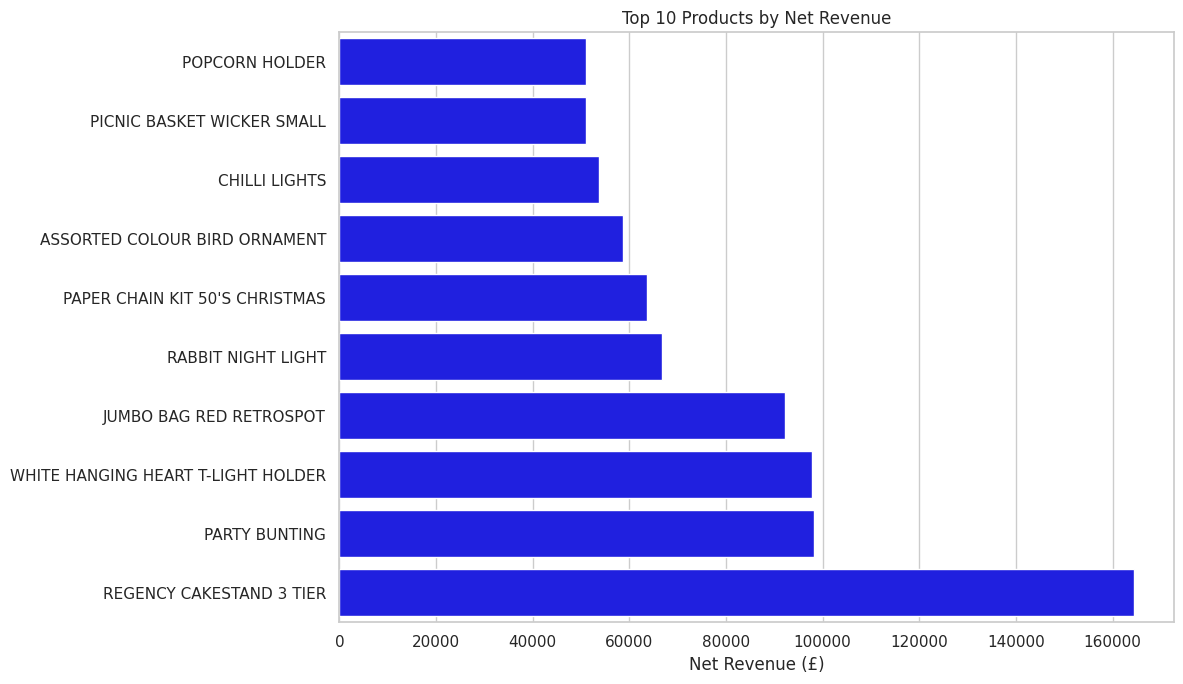

In [41]:
revenue_plot_data = (
    top_by_net_revenue
    .sort_values("NetRevenue")
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=revenue_plot_data,
    x="NetRevenue",
    y="ProductName",
    color="blue"
)

plt.title("Top 10 Products by Net Revenue")
plt.xlabel("Net Revenue (£)")
plt.ylabel("")
plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "top_products_by_net_revenue.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

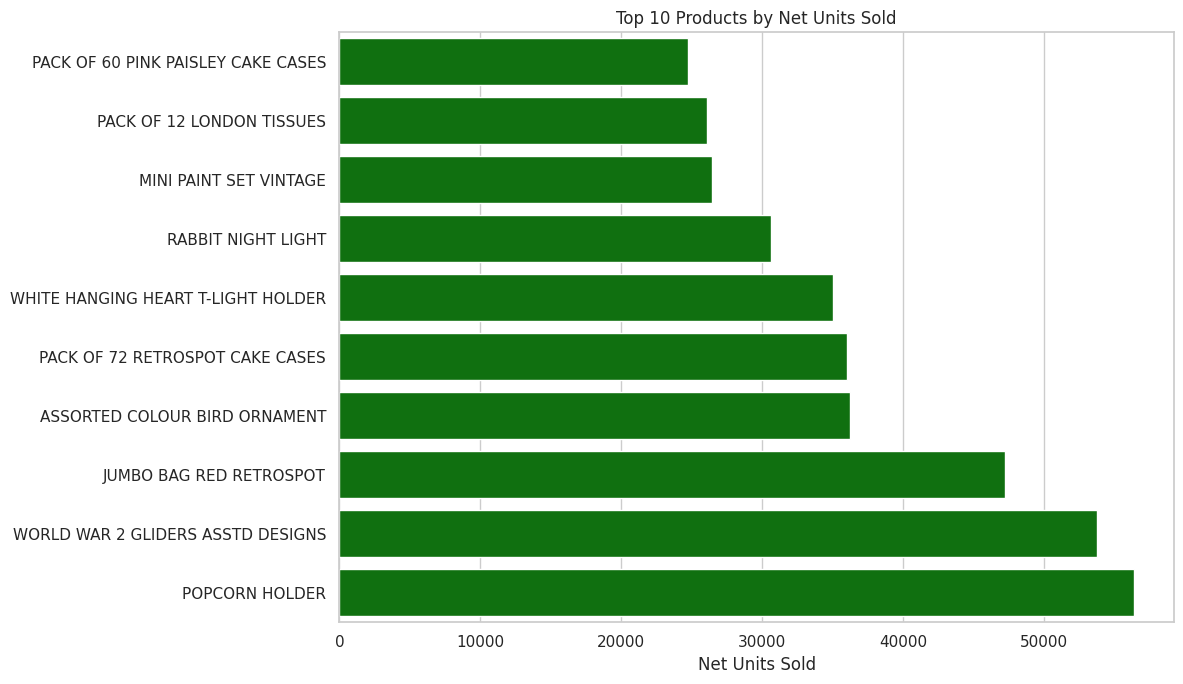

In [42]:
units_plot_data = (
    top_by_net_units
    .sort_values("NetUnits")
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=units_plot_data,
    x="NetUnits",
    y="ProductName",
    color= "green"
)

plt.title("Top 10 Products by Net Units Sold")
plt.xlabel("Net Units Sold")
plt.ylabel("")
plt.tight_layout()

plt.savefig(
    IMAGES_DIR / "top_products_by_net_units.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

### Product findings

- REGENCY CAKESTAND 3 TIER generated the highest net product revenue at £164,459.49.
- POPCORN HOLDER had the highest net sales volume with 56,427 units sold.
- WHITE HANGING HEART T-LIGHT HOLDER appeared in the largest number of orders, indicating consistent customer demand.
- The revenue and volume rankings differ because inexpensive products can sell in large quantities without generating the highest revenue.
- Large cancelled transactions were removed from the net rankings to avoid overstating product performance.